seed locked to 42
disease-gene map:8 diseases loaded
gene sequences loaded from disk: 8
crispr papers loaded from disk: 669

sample gene
gene:CCR5|length:3661 bp
sequence preview:CTTCAGATAGATTATATCTGGAGTGAAGAATCCTGCCACCTATGTATCTGGCATAGTATT

sample papers

[1] CRISPR-Cas9: a new and promising player in gene therapy.
year:2015|query:CRISPR therapeutic gene correction
abstract:First introduced into mammalian organisms in 2013, the RNA-guided genome editing tool CRISPR-Cas9 (clustered regularly i

[2] CRISPR/Cas9 Mediated Therapeutic Approach in Huntington's Disease.
year:2023|query:CRISPR therapeutic gene correction
abstract:The pathogenic mechanisms of these diseases must be well understood for the treatment of neurological disorders such as 

[3] RNA-Targeting CRISPR/CasRx system relieves disease symptoms in Huntington's dise
year:2025|query:CRISPR Huntington disease HTT
abstract:BACKGROUND: HD is a devastating neurodegenerative disorder caused by the expansion of CAG repeats in the HTT

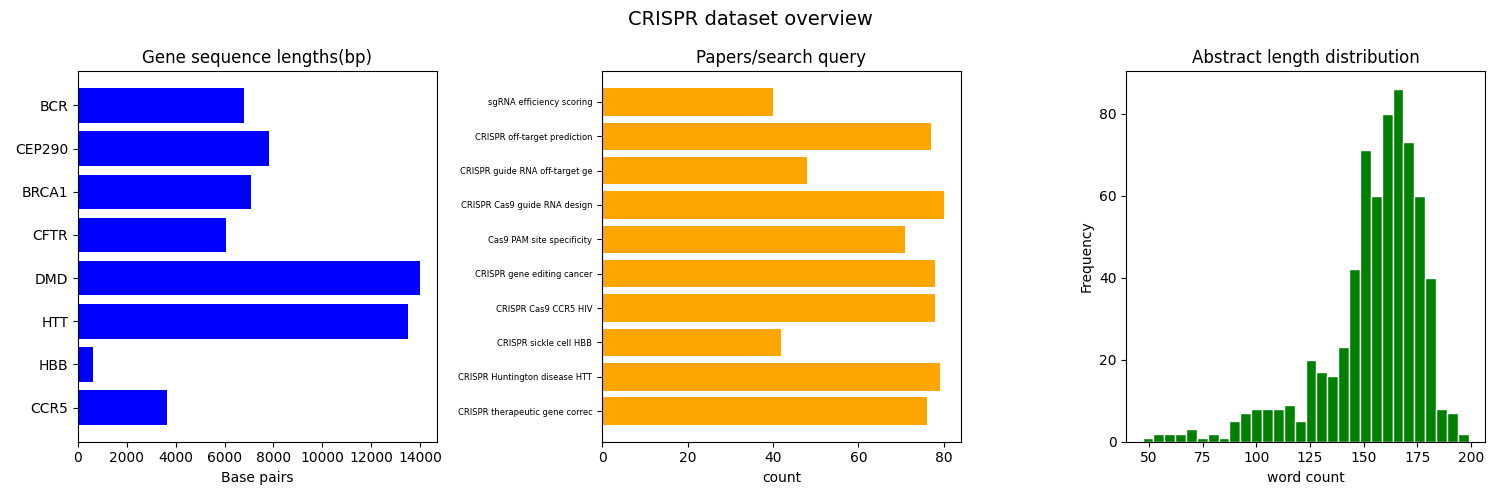

30

In [1]:
#cell 1 setup and data loading
import os
import re
import gc
import json
import random
import warnings
import time
from IPython.display import Image, display
#ignoring warnings and setting up env vars
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"]="false"
os.environ["HF_DATASETS_DISABLE_PROGRESS_BARS"]="1"
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"]="1"
os.environ["ENTREZ_EMAIL"]="your_email@example.com"
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from Bio import Entrez, SeqIO, Medline
from datasets import disable_caching
disable_caching()

#locking randomness for reproducibility
SEED=42
random.seed(SEED)
np.random.seed(SEED)
print(f"seed locked to {SEED}")
Results_folder=r"C:\Users\user\Desktop\CRISPR-Cas9-Engineering-Platform-RAG\Results"
FROZEN_DIR=os.path.join(Results_folder,"frozen_data")
CACHE_DIR=r"C:\Users\user\Desktop\CRISPR-Cas9-Engineering-Platform-RAG\hf_cache"
os.makedirs(Results_folder,exist_ok=True)
os.makedirs(FROZEN_DIR,exist_ok=True)
os.makedirs(CACHE_DIR,exist_ok=True)

#disease gene map with refseq ids verified 
DISEASE_GENE_MAP={
    "HIV":{"gene":"CCR5","refseq":"NM_000579"},
    "Sickle Cell":{"gene":"HBB","refseq":"NM_000518"},
    "Huntington's":{"gene":"HTT","refseq":"NM_002111"},
    "Duchenne MD":{"gene":"DMD","refseq":"NM_004006"},
    "Cystic Fibrosis":{"gene":"CFTR","refseq":"NM_000492"},
    "BRCA Cancer":{"gene":"BRCA1","refseq":"NM_007294"},
    "Blindness (LCA)":{"gene":"CEP290","refseq":"NM_025114"},
    "Leukemia":{"gene":"BCR","refseq":"NM_004327"},
}
print(f"disease-gene map:{len(DISEASE_GENE_MAP)} diseases loaded")
Entrez.email="ishan.sharma.ug24@nsut.ac.in"

#fetching gene sequence from ncbi nucleoide db
def fetch_sequence(refseq_id,gene_name):
    try:
        handle=Entrez.efetch(db="nucleotide",id=refseq_id,rettype="fasta",retmode="text")
        record=SeqIO.read(handle,"fasta")
        handle.close()
        return {"gene":gene_name,"refseq":refseq_id,
                "sequence":str(record.seq),"length":len(record.seq)}
    except Exception as e:
        print(f"failed {gene_name}:{e}")
        return None
SEQ_PATH=os.path.join(FROZEN_DIR,"gene_sequences.json")

if os.path.exists(SEQ_PATH):
    with open(SEQ_PATH,encoding="utf-8") as f:
        gene_sequences=json.load(f)
    print(f"gene sequences loaded from disk: {len(gene_sequences)}")              
else:
    print("fetching gene sequences from NCBI nucleotide")
    gene_sequences={}
    for disease,info in DISEASE_GENE_MAP.items():
        print(f"  fetching {info['gene']}:",end=" ")
        result=fetch_sequence(info["refseq"],info["gene"])
        if result:
            gene_sequences[info["gene"]]=result
            print(f"{result['length']} bp")
        time.sleep(0.4)#time pause added to avoid hitting ncbi rate limits
    #freezing sequences to disk for reproducibility
    with open(SEQ_PATH,"w",encoding="utf-8") as f:
        json.dump(gene_sequences,f,ensure_ascii=False,indent=2)
    print(f"sequences frozen:{SEQ_PATH}")

PAPERS_PATH=os.path.join(FROZEN_DIR,"crispr_papers.json")
#queries to seach crispr literature multiple queries for wide coverage
PUBMED_QUERIES=[
    "CRISPR Cas9 guide RNA design",
    "CRISPR off-target prediction",
    "sgRNA efficiency scoring",
    "CRISPR gene editing cancer",
    "CRISPR Cas9 CCR5 HIV",
    "CRISPR Huntington disease HTT",
    "CRISPR sickle cell HBB",
    "CRISPR guide RNA off-target genome",
    "Cas9 PAM site specificity",
    "CRISPR therapeutic gene correction",
]
#fetching papers from pubmed
def fetch_pubmed_papers(query,max_results=80):
    #searching for paper ids
    search_handle=Entrez.esearch(
        db="pubmed",
        term=query,
        retmax=max_results,
        sort="relevance"
    )
    search_results=Entrez.read(search_handle)
    search_handle.close()
    ids=search_results["IdList"]
    if not ids:
        return []
    time.sleep(0.4)

    #fetching abstaracts of for ids
    fetch_handle=Entrez.efetch(
        db="pubmed",
        id=",".join(ids),
        rettype="medline",
        retmode="text"
    )
    records=list(Medline.parse(fetch_handle))
    fetch_handle.close()
    time.sleep(0.4)

    papers=[]
    for r in records:
        title=r.get("TI","").strip()
        abstract=r.get("AB","").strip()
        authors=r.get("AU",[])
        year=r.get("DP","")[:4]
        #filter
        if not abstract or len(abstract)<100:
            continue
        #sturcturing the output
        papers.append({
            "title":title,
            "abstract":abstract[:1200],
            "authors":authors[:3],
            "year":year,
            "query":query,
            "source":"PubMed"
        })
    return papers
if os.path.exists(PAPERS_PATH):
    with open(PAPERS_PATH,encoding="utf-8") as f:
        papers=json.load(f)
    print(f"crispr papers loaded from disk: {len(papers)}")
else:
    print("fetching CRISPR papers from PubMed")
    all_papers=[]
    seen_titles=set()

    for query in PUBMED_QUERIES:
        print(f"  searching: '{query}':",end=" ")
        try:
            results=fetch_pubmed_papers(query,max_results=80)
            added=0
            for p in results:
                #deduplicate by title
                if p["title"] not in seen_titles and p["title"]:
                    seen_titles.add(p["title"])
                    all_papers.append(p)
                    added+=1
            print(f"{added} papers")
        except Exception as e:
            print(f"failed ({e})")
    #shuffling for unbiased ordering
    random.shuffle(all_papers)
    papers=all_papers
    print(f"\ntotal unique CRISPR papers:{len(papers)}")
    with open(PAPERS_PATH,"w",encoding="utf-8") as f:
        json.dump(papers,f,ensure_ascii=False,indent=2)
    print(f"papers frozen: {PAPERS_PATH}")

#rules for gRNA design and ranking as per doench 2016
DOENCH_WEIGHTS={"gc_min":0.40,"gc_max":0.70,"gc_ideal":0.55,"poly_t_len":4,"seed_region":12,"pam":"NGG"}

#quick check
print("\nsample gene")
s=list(gene_sequences.values())[0]
print(f"gene:{s['gene']}|length:{s['length']} bp")
print(f"sequence preview:{s['sequence'][:60]}")

print("\nsample papers")
for i in range(3):
    print(f"\n[{i+1}] {papers[i]['title'][:80]}")
    print(f"year:{papers[i]['year']}|query:{papers[i]['query']}")
    print(f"abstract:{papers[i]['abstract'][:120]}")

#visualisation
fig,axes=plt.subplots(1,3,figsize=(15,5))
fig.suptitle("CRISPR dataset overview",fontsize=14)
genes=[g for g in gene_sequences]
lengths=[gene_sequences[g]["length"] for g in genes]
axes[0].barh(genes,lengths,color="blue")
axes[0].set_title("Gene sequence lengths(bp)")
axes[0].set_xlabel("Base pairs")
query_counts={}
for p in papers:
    q=p["query"][:30]
    query_counts[q]=query_counts.get(q,0)+1
axes[1].barh(list(query_counts.keys()),list(query_counts.values()),color="orange")
axes[1].set_title("Papers/search query")
axes[1].set_xlabel("count")
axes[1].tick_params(axis='y',labelsize=6)

abstract_lengths=[len(p["abstract"].split()) for p in papers]
axes[2].hist(abstract_lengths,bins=30,color="green",edgecolor="white")
axes[2].set_title("Abstract length distribution")
axes[2].set_xlabel("word count")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plot_out=os.path.join(Results_folder, "cell1_overview.png")
plt.savefig(plot_out, dpi=100)
plt.close()
display(Image(filename=plot_out))
gc.collect()

gene sequences loaded: 8 genes

scanning genes for guide RNA candidates

 CCR5:258 found,234 passed filter
[1] CCTCACTGCAAGCACTGCATscore:90/100GC:55.0%  off-target:Low
[2] GATGGCCTCTGCTAAGCTCAscore:88/100GC:55.0%  off-target:Low
[3] GGATGCAGAGTCAGCAGAACscore:88/100GC:55.0%  off-target:Low
[4] CTAAGCTCAAGGCGTGAGGAscore:87/100GC:55.0%  off-target:Low
[5] CCTGACAATCGATAGGTACCscore:85/100GC:50.0%  off-target:Low

 HBB:52 found,52 passed filter
[1] GCTCACCTGGACAACCTCAAscore:90/100GC:55.0%  off-target:Low
[2] GGCTCACCTGGACAACCTCAscore:86/100GC:60.0%  off-target:Low
[3] AAGGTGAACGTGGATGAAGTscore:81/100GC:45.0%  off-target:Low
[4] CATGGTGCATCTGACTCCTGscore:80/100GC:55.0%  off-target:Medium
[5] GTGAACGTGGATGAAGTTGGscore:80/100GC:50.0%  off-target:Low

 HTT:948 found,866 passed filter
[1] CCTGCCATGGACCTGAATGAscore:90/100GC:55.0%  off-target:Low
[2] GACGCTGACAGAACTGCGAAscore:90/100GC:55.0%  off-target:Low
[3] GGTGATGCTGTCTGGAAGTGscore:90/100GC:55.0%  off-target:Low
[4] ATCGCTGGTCAAGCTGAGTGscore:9

,Gene,Rank,Guide RNA,Score,GC %,PAM,Position,Off-target
0,CCR5,1,CCTCACTGCAAGCACTGCAT,90,55.0,GGG,2061,Low
1,CCR5,2,GATGGCCTCTGCTAAGCTCA,88,55.0,AGG,2308,Low
2,CCR5,3,GGATGCAGAGTCAGCAGAAC,88,55.0,TGG,2399,Low
3,CCR5,4,CTAAGCTCAAGGCGTGAGGA,87,55.0,TGG,2319,Low
4,CCR5,5,CCTGACAATCGATAGGTACC,85,50.0,TGG,719,Low
5,HBB,1,GCTCACCTGGACAACCTCAA,90,55.0,GGG,278,Low
6,HBB,2,GGCTCACCTGGACAACCTCA,86,60.0,AGG,277,Low
7,HBB,3,AAGGTGAACGTGGATGAAGT,81,45.0,TGG,101,Low
8,HBB,4,CATGGTGCATCTGACTCCTG,80,55.0,AGG,49,Medium
9,HBB,5,GTGAACGTGGATGAAGTTGG,80,50.0,TGG,104,Low


table saved


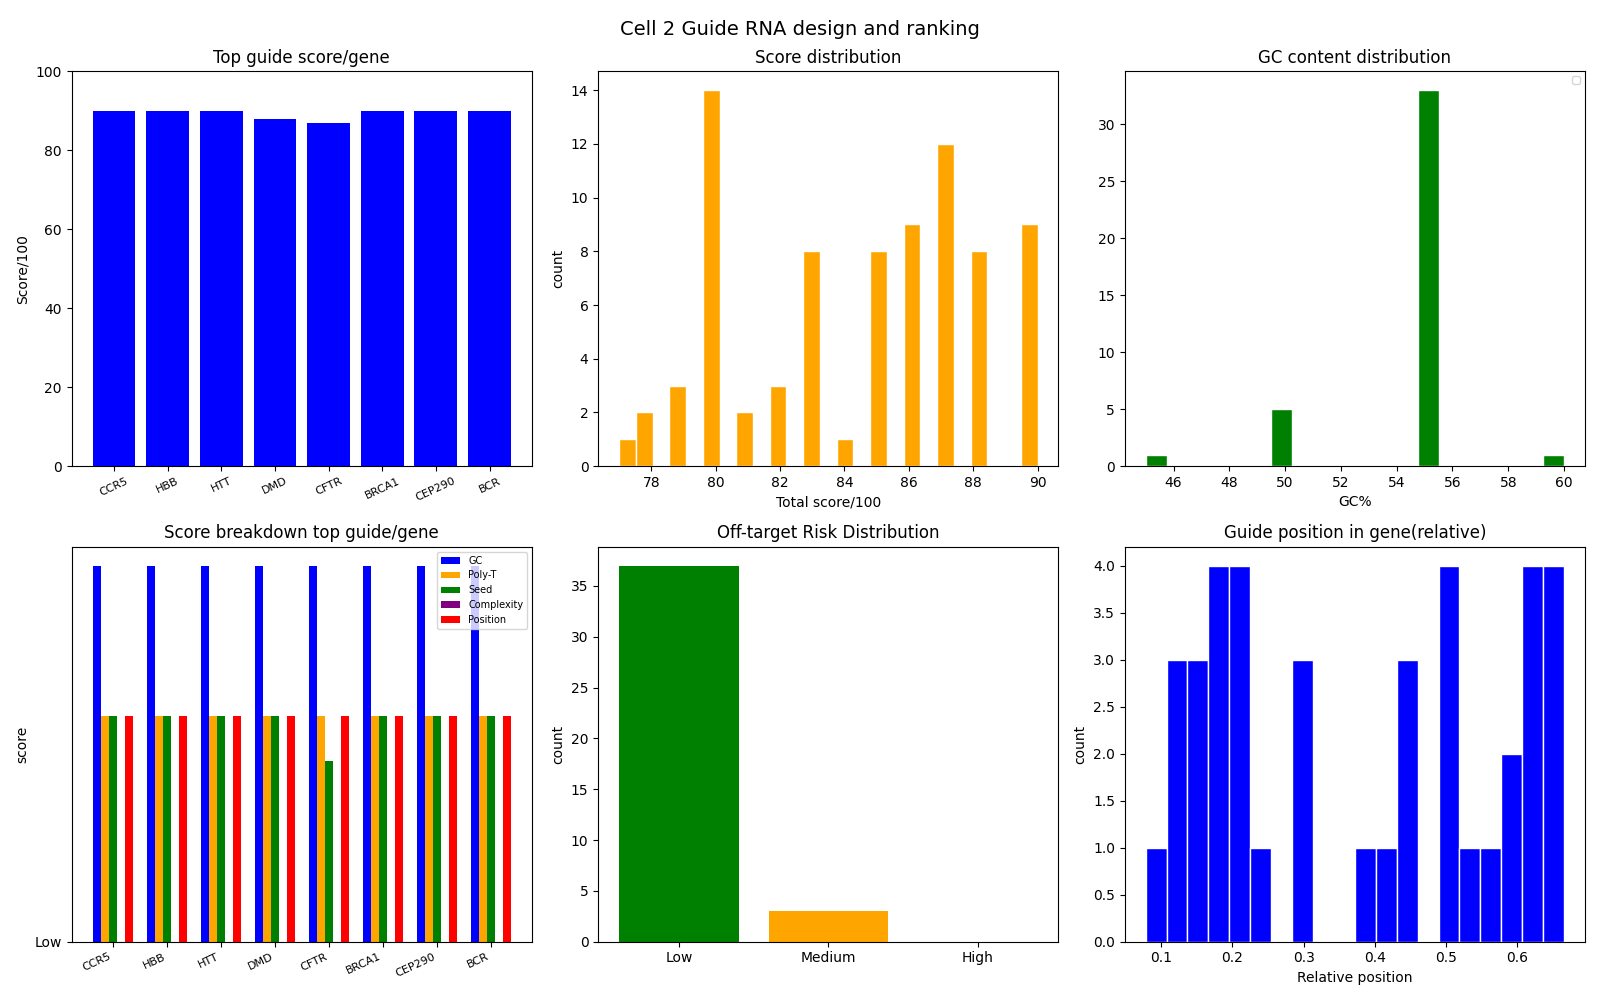

In [2]:
#cell 2 guide rna design and ranking engine
#5 scoring criterias based on doench 2016
#real scoring needs bowtie (future work) so rn heuristic approach
import pandas as pd
Results_folder=r"C:\Users\user\Desktop\CRISPR-Cas9-Engineering-Platform-RAG\Results"
FROZEN_DIR=os.path.join(Results_folder,"frozen_data")

with open(os.path.join(FROZEN_DIR,"gene_sequences.json"),encoding="utf-8") as f:
    gene_sequences=json.load(f)
print(f"gene sequences loaded: {len(gene_sequences)} genes")

#pam scanner to generate crispr guide rna candidates (ngg sites)
def find_candidates(sequence,gene_name):
    sequence=sequence.upper()
    candidates=[]
    for i in range(len(sequence)-23):
        pam=sequence[i+20:i+23]
        if pam[1:]=="GG" and all(c in "ATCG" for c in sequence[i:i+20]):
            candidates.append({
                "gene":gene_name,
                "guide_rna":sequence[i:i+20],
                "pam":pam,
                "position":i,
            })
    return candidates

#scoring functions for guide rna ranking
#gc content scoring func for guide rna stability(25 pt w)
#gc content controls stability and binding efficiency
def gc_score(guide):
    gc=sum(1 for c in guide if c in "GC")/20
    if gc<0.30 or gc>0.80:
        return 0,round(gc*100,1)
    if gc<0.40:
        return int((gc/0.40)*15),round(gc*100,1)
    if gc>0.70:
        return int(((0.80-gc)/0.10)*15),round(gc*100,1)
    score=int(25-(abs(gc-0.55)*80))
    return max(0,score), round(gc*100,1)

#poly t run penalty func(transcription termination risk 15 pt w)
#polyt runs reduce transcription eff due to termination signals
def poly_t_score(guide):
    run=max((len(m.group()) for m in re.finditer(r'T+',guide)),default=0)
    if run>=4:
        return 0
    if run==3:
        return 5
    if run==2:
        return 10
    return 15

#seed region scoring func(last 12 nt before pam,25 pt w)
#seed region controls target binding specificity & of target sensitivity
def seed_score(guide):
    seed=guide[-12:]
    gc=sum(1 for c in seed if c in "GC")/12
    if gc<0.25 or gc>0.75:
        return 0
    #gc content in seed region(0-15 pt)
    score=int(15-(abs(gc-0.50)*30))
    score=max(8,score)
    #penalising repeats found in seed
    repeats=sum(1 for i in range(0,10,2) if seed[i:i+2]==seed[i+2:i+4])
    score-=repeats*3
    #penalising homopolymers in seed
    for base in "ATCG":
        if base*3 in seed: 
            score-=5
    return max(0,min(25,score))

#off target/complexity_Score using sequence complexity & repetitiveness(20 pt w)
#off target proxy done in heuristic way for now & its not that good
#real implementation would use bowtie genome alignment(future work for phase 2)
def off_target(guide):
    score=20
    #penalty for low seq complexity
    if len(set(guide))<=2:
        return 0
    if len(set(guide))==3:
        score-=8
    #penalty for dinucleotide repeats
    dinuc=sum(1 for i in range(18) if guide[i:i+2]==guide[i+2:i+4])
    score-=min(10,dinuc*2)
    #penaly for homopolymer runs
    for b in "ATCG":
        runs=re.findall(f'{b}{{3,}}',guide)
        score-=sum(len(r)-2 for r in runs)*2
    #penalty for high gc at cut site
    if sum(1 for c in guide[-4:] if c in "GC")>=3:
        score-=5
    return max(0,min(20,score))

#position score for guide rna(15 pt w)
#guides in coding region are more effective for gene knockout
def position_score(position, seq_length):
    rel=position/seq_length
    if rel<0.05 or rel>0.90:
        return 5
    if 0.10<=rel<=0.70:
        return 15
    return 10

##combined guide rna scorer(100 pt)
#gc(25)+poly t(15)+seed(25)+offtarget(20)+position(15)
def score_candidate(c, seq_length):
    guide=c["guide_rna"]
    g,gc_pct=gc_score(guide)
    p=poly_t_score(guide)
    s=seed_score(guide)
    ot=off_target(guide)
    pos=position_score(c["position"],seq_length)
    total=g+p+s+ot+pos
    ot="Low" if ot>=17 else "Medium" if ot>=10 else "High" #complexity score risk label
    return {**c,"gc_pct":gc_pct,"gc_score":g,"poly_t":p,
            "seed":s,"complexity":ot,"position_pts":pos,
            "total_score":total,"off_target_risk":ot}

#run guide rna gen & scoring pipeline across all genes
print("\nscanning genes for guide RNA candidates")
all_results={}

for gene,data in gene_sequences.items():
    seq=data["sequence"]
    candidates=find_candidates(seq,gene)
    scored=[score_candidate(c,len(seq)) for c in candidates]
    #rank guides by total score & store top guides/gene
    scored=[s for s in scored if s["total_score"]>=40]
    scored=sorted(scored,key=lambda x:x["total_score"],reverse=True)
    all_results[gene]=scored[:10]

    print(f"\n {gene}:{len(candidates)} found,{len(scored)} passed filter")
    for i,r in enumerate(scored[:5],1):
        print(f"[{i}] {r['guide_rna']}"
              f"score:{r['total_score']}/100"
              f"GC:{r['gc_pct']}%  "
              f"off-target:{r['off_target_risk']}")

with open(os.path.join(FROZEN_DIR,"ranked_guides.json"),"w",encoding="utf-8") as f:
    json.dump(all_results,f,ensure_ascii=False,indent=2)
print(f"\nranked guides saved")

#table
rows=[]
for gene,guides in all_results.items():
    for rank,g in enumerate(guides[:5],1):
        rows.append({
            "Gene":gene,
            "Rank":rank,
            "Guide RNA":g["guide_rna"],
            "Score":g["total_score"],
            "GC %":g["gc_pct"],
            "PAM":g["pam"],
            "Position":g["position"],
            "Off-target":g["off_target_risk"],
        })
df=pd.DataFrame(rows)
display(df)
df.to_csv(os.path.join(Results_folder,"top_guide_rnas.csv"),index=False)
print("table saved")

#visualisation
fig,axes=plt.subplots(2,3,figsize=(16,10))
fig.suptitle("Cell 2 Guide RNA design and ranking",fontsize=14)
top_scores={g:all_results[g][0]["total_score"]for g in all_results if all_results[g]}
axes[0,0].bar(top_scores.keys(),top_scores.values(),color="blue")
axes[0,0].set_title("Top guide score/gene")
axes[0,0].set_ylabel("Score/100")
axes[0,0].tick_params(axis='x',rotation=25,labelsize=8)
axes[0,0].set_ylim(0,100)
all_scores=[g["total_score"] for gene in all_results.values() for g in gene]
axes[0,1].hist(all_scores,bins=25,color="orange",edgecolor="white")
axes[0,1].set_title("Score distribution")
axes[0,1].set_xlabel("Total score/100")
axes[0,1].set_ylabel("count")

all_gc=[g["gc_pct"] for gene in all_results.values() for g in gene[:5]]
axes[0,2].hist(all_gc,bins=20,color="green",edgecolor="white")
axes[0,2].set_title("GC content distribution")
axes[0,2].set_xlabel("GC%")
axes[0,2].legend(fontsize=7)
genes_list=[g for g in all_results if all_results[g]]
comp_data={
    "GC":[all_results[g][0]["gc_score"] for g in genes_list],
    "Poly-T":[all_results[g][0]["poly_t"] for g in genes_list],
    "Seed":[all_results[g][0]["seed"] for g in genes_list],
    "Complexity":[all_results[g][0]["complexity"] for g in genes_list],
    "Position":[all_results[g][0]["position_pts"] for g in genes_list],
}
x=np.arange(len(genes_list))
w=0.15
colors=["blue","orange","green","purple","red"]
for idx,(label,vals) in enumerate(comp_data.items()):
    axes[1,0].bar(x+(idx-2)*w,vals,w,label=label,color=colors[idx])
axes[1,0].set_title("Score breakdown top guide/gene")
axes[1,0].set_ylabel("score")
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(genes_list,rotation=25,ha="right",fontsize=8)
axes[1,0].legend(fontsize=7)

ot_counts={"Low":0,"Medium":0,"High":0}
for gene in all_results.values():
    for g in gene[:5]:
        ot_counts[g["off_target_risk"]]+=1
axes[1,1].bar(ot_counts.keys(),ot_counts.values(),
              color=["green","orange","red"])
axes[1,1].set_title("Off-target Risk Distribution")
axes[1,1].set_ylabel("count")

all_pos=[g["position"]/gene_sequences[g["gene"]]["length"]
         for gene in all_results.values() for g in gene[:5]]
axes[1,2].hist(all_pos,bins=20,color="blue",edgecolor="white")
axes[1,2].set_title("Guide position in gene(relative)")
axes[1,2].set_xlabel("Relative position")
axes[1,2].set_ylabel("count")
plt.tight_layout()
plot_out=os.path.join(Results_folder, "cell2_guide_rna_ranking.png")
plt.savefig(plot_out, dpi=100)
plt.close()
display(Image(filename=plot_out))

In [3]:
#cell 3 llm baseline model 
#shows how an llm performs wrt to rag in next cell
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

Results_folder=r"C:\Users\user\Desktop\CRISPR-Cas9-Engineering-Platform-RAG\Results"
FROZEN_DIR=os.path.join(Results_folder,"frozen_data")
model_name="Qwen/Qwen2.5-7B-Instruct"
tokenizer=AutoTokenizer.from_pretrained(model_name)
model=AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float16,
    device_map={"": 0}
)
model.eval()
print("model loaded")

#eval questions 1/disease will be used to compare llm alone vs rag(including llm)
EVAL_QUESTIONS={
    "CCR5":"What is the best guide RNA sequence for knocking out CCR5 in human T-cells for HIV resistance? What design criteria should I use?",
    "HBB":"How should I design a guide RNA to correct the sickle cell mutation in the HBB gene? What region should I target?",
    "HTT":"What guide RNA design strategy should I use to silence the HTT gene for Huntington's disease therapy?",
    "DMD":"How do I design a guide RNA for exon skipping in the DMD gene to treat Duchenne muscular dystrophy?",
    "CFTR":"What is the best approach to design a guide RNA targeting the F508del mutation region in CFTR for cystic fibrosis?",
    "BRCA1":"How should I design guide RNAs to study BRCA1 function in DNA repair? What exons should I target?",
    "CEP290":"What guide RNA design considerations are important for targeting CEP290 for Leber congenital amaurosis treatment?",
    "BCR":"How do I design a guide RNA to disrupt the BCR-ABL fusion gene in CML leukemia cells?",
}
def generate_response(question, max_new_tokens=200):
    messages=[{"role":"user","content":question}]
    inputs=tokenizer.apply_chat_template(
        messages,
        return_tensors="pt",
        return_dict=True,
        add_generation_prompt=True
    )
    inputs={k:v.to(model.device) for k,v in inputs.items()}
    with torch.no_grad():
        outputs=model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.2,
            eos_token_id=tokenizer.eos_token_id
        )
    response=tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[-1]:],
        skip_special_tokens=True
    )
    del inputs,outputs
    return response

print("\ngenerating LLM responses(no RAG)")
llm_responses={}
for gene,question in EVAL_QUESTIONS.items():
    print(f"{gene}:",end=" ")
    response=generate_response(question)
    llm_responses[gene]={
        "question":question,
        "response":response,
        "model":model_name,
        "context":"none LLM only"
    }
#quick loss check(how confident model is on crispr domain)
print("\nrunning loss check on crispr question")
test_msg=[{"role":"user","content":"What is a PAM site in CRISPR Cas9?"}]
test_inputs=tokenizer.apply_chat_template(
    test_msg,
    return_tensors="pt",
    return_dict=True
)
test_inputs={k:v.to(model.device) for k,v in test_inputs.items()}
with torch.no_grad():
    loss_output=model(**test_inputs,labels=test_inputs["input_ids"])
    print(f"loss:{loss_output.loss.item():.4f}")

#saving llm response to disk
LLM_PATH=os.path.join(FROZEN_DIR,"llm_responses.json")
with open(LLM_PATH,"w",encoding="utf-8") as f:
    json.dump(llm_responses,f,ensure_ascii=False,indent=2)
print(f"\nllm responses saved: {LLM_PATH}")

print("\nsample llm responses(1st 3 genes)")
for gene in list(llm_responses.keys())[:3]:
    print(f"\n[{gene}]")
    print(f"Q: {llm_responses[gene]['question']}")
    print(f"A: {llm_responses[gene]['response']}")

Loading weights: 100%|██████████| 339/339 [00:04<00:00, 69.45it/s]


model loaded

generating LLM responses(no RAG)
CCR5: HBB: HTT: DMD: CFTR: BRCA1: CEP290: BCR: 
running loss check on crispr question
loss:4.0214

llm responses saved: C:\Users\user\Desktop\CRISPR-Cas9-Engineering-Platform-RAG\Results\frozen_data\llm_responses.json

sample llm responses(1st 3 genes)

[CCR5]
Q: What is the best guide RNA sequence for knocking out CCR5 in human T-cells for HIV resistance? What design criteria should I use?
A: Knocking out the CCR5 gene to confer HIV resistance involves designing guide RNAs (gRNAs) that will be used with CRISPR-Cas9 technology. The goal is to create double-strand breaks at specific sites within the CCR5 locus so that homology-directed repair can introduce deletions or other modifications.

### Design Criteria for gRNA Sequences:

1. **Target Specificity:**
   - Ensure high specificity of your target site(s). Use tools like CasPep, CHOPCHOP, or CRISPRseek to predict potential off-target effects.
   - Aim for unique sequences around 20 nucle

In [4]:
#cell 4 rag(with llm) 
#will be compared by cell 3 in cell 5
#retrieves crispr papers & ranked guide rnas then feeds to llm
import shutil
import gc as gc1
from transformers import AutoTokenizer, AutoModelForCausalLM,BitsAndBytesConfig, pipeline
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_community.vectorstores import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.llms import HuggingFacePipeline
from typing import List, Set

Results_folder=r"C:\Users\user\Desktop\CRISPR-Cas9-Engineering-Platform-RAG\Results"
FROZEN_DIR=os.path.join(Results_folder,"frozen_data")
CHROMA_DIR=os.path.join(FROZEN_DIR,"chroma_db")

#loading data
with open(os.path.join(FROZEN_DIR,"crispr_papers.json"),encoding="utf-8") as f:
    papers=json.load(f)
print(f"papers loaded:{len(papers)}")

with open(os.path.join(FROZEN_DIR,"ranked_guides.json"),encoding="utf-8") as f:
    ranked_guides=json.load(f)
print(f"ranked guides loaded: {len(ranked_guides)} genes")

#confirming feild names
sample_gene=list(ranked_guides.keys())[0]
sample_guide=ranked_guides[sample_gene][0]
print(f"\nfield check{sample_gene}:{list(sample_guide.keys())}")
print(f"sample:{sample_guide}")
EVAL_QUESTIONS={
    "CCR5":"What is the best guide RNA sequence for knocking out CCR5 in human T-cells for HIV resistance? What design criteria should I use?",
    "HBB":"How should I design a guide RNA to correct the sickle cell mutation in the HBB gene? What region should I target?",
    "HTT":"What guide RNA design strategy should I use to silence the HTT gene for Huntington's disease therapy?",
    "DMD":"How do I design a guide RNA for exon skipping in the DMD gene to treat Duchenne muscular dystrophy?",
    "CFTR":"What is the best approach to design a guide RNA targeting the F508del mutation region in CFTR for cystic fibrosis?",
    "BRCA1":"How should I design guide RNAs to study BRCA1 function in DNA repair? What exons should I target?",
    "CEP290":"What guide RNA design considerations are important for targeting CEP290 for Leber congenital amaurosis treatment?",
    "BCR":"How do I design a guide RNA to disrupt the BCR-ABL fusion gene in CML leukemia cells?",
}
GENE_DISEASE={
    "CCR5":"HIV","HBB":"Sickle Cell","HTT":"Huntington's",
    "DMD":"Duchenne MD","CFTR":"Cystic Fibrosis",
    "BRCA1":"BRCA Cancer","CEP290":"Blindness (LCA)","BCR":"Leukemia",
}

#build doc corpus cuz papers get chunked guide docs will remain as whole not chunked
paper_docs=[]
for p in papers:
    paper_docs.append(Document(  
        page_content=f"Title: {p['title']}\n\nAbstract: {p['abstract']}",
        metadata={"source":"PubMed","type":"paper"}
    ))
guide_docs=[]
for gene,guides in ranked_guides.items():
    disease=GENE_DISEASE.get(gene,gene)
    #get feild names from loaded data
    lines=[
        f"CRISPR guide RNA design results for {gene} gene targeting {disease}.",
        f"Computationally ranked guide RNA sequences for {gene} using CRISPR-Cas9.",
        f"Use these sequences for experimental design. All require wet lab validation.",
        "",
        f"Top 5 ranked guide RNAs for {gene}:",
    ]
    for i,g in enumerate(guides[:5],1):
        seq=g["guide_rna"]
        score=g["total_score"]
        gc=g["gc_pct"]
        ot=g["off_target_risk"]
        pos=g["position"]
        lines.append(f"Rank {i}:{seq}|Score:{score}/100| "f"GC:{gc}%|Off-target:{oct}|Position:{pos}")
    lines.append(f"\nScoring criteria:GC content,seed region,poly-T,complexity,position.")
    guide_docs.append(Document(
        page_content="\n".join(lines),
        metadata={"source":"Cell2-Scorer","type":"guide","gene":gene}
    ))

#verifying guide doc content before building vectorstore
print("\nguide doc verification")
for doc in guide_docs[:2]:
    print(f"\n{doc.page_content[:300]}")
    print("contains actual sequences:",any(len(w)==20 and all(c in "ATCG" for c in w)for w in doc.page_content.split()))

#chunking papers
splitter=RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50,
    separators=["\n\n","\n"," "]
)
paper_chunks=splitter.split_documents(paper_docs)
all_chunks=paper_chunks+guide_docs
print(f"\npaper chunks:{len(paper_chunks)}")
print(f"guide docs (whole):{len(guide_docs)}")
print(f"total:{len(all_chunks)}")

#vector store
if os.path.exists(CHROMA_DIR):
    shutil.rmtree(CHROMA_DIR)
    print("stale chroma cache cleared")
embeddings=HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)
print(f"embedding dims:{len(embeddings.embed_query('test'))}")
vectorstore=Chroma.from_documents(
    documents=all_chunks,
    embedding=embeddings,
    persist_directory=CHROMA_DIR,
    collection_name="crispr_papers"
)
#mmr retrieval(prevents all pubmed bias by penalising redundant results)
retriever=vectorstore.as_retriever(
    search_type="mmr",
    search_kwargs={"k":6,"fetch_k":20,"lambda_mult":0.5}
)

#testing retrieval
print("\nretrieval test:")
test_docs=retriever.invoke("guide RNA CCR5 HIV sequence score")
for i,doc in enumerate(test_docs,1):
    print(f"[{i}] {doc.metadata['source']}|{doc.page_content[:80]}")

#loading LLM
print("\nloading LLM")
model_name="Qwen/Qwen2.5-7B-Instruct"
tokenizer=AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token=tokenizer.eos_token
bnb_config=BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True
)
llm_model=AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    low_cpu_mem_usage=True
)
pipe=pipeline(
    "text-generation",
    model=llm_model,
    tokenizer=tokenizer,
    max_new_tokens=250,
    do_sample=False,
    repetition_penalty=1.2,
    return_full_text=False
)
llm=HuggingFacePipeline(pipeline=pipe)
print("llm loaded")

#prompt+rag chain
prompt = PromptTemplate.from_template("""
You are a CRISPR guide RNA design assistant for biomedical researchers.
CRITICAL RULES:
Use ONLY the retrieved context.
Copy guide RNA sequences EXACTLY as written.
Include exact score values (e.g., 90/100).
Do NOT invent or modify sequences.
RESPONSE STYLE:
Be concise but clear.
Prefer short explanations backed by retrieved evidence.
Avoid long theoretical discussions unless present in context.
Retrieved context:
{context}
Question:
{question}
Answer:
""")
def format_docs(docs):
    return "\n\n".join(
        f"[{i+1}] (Source: {doc.metadata['source']})\n{doc.page_content}"
        for i,doc in enumerate(docs))

rag_chain=(
    {"context":retriever|RunnableLambda(format_docs),
    "question":RunnablePassthrough()}
    |prompt
    |llm
    |StrOutputParser()
)

def rag_with_sources(question):
    answer=rag_chain.invoke(question)
    sources=retriever.invoke(question)
    return {"answer":answer,"sources":sources}

#gen reponses of all 8 genes
print("\ngenerating RAG+LLM responses")
rag_responses={}
for gene,question in EVAL_QUESTIONS.items():
    print(f"{gene}:",end=" ")
    result=rag_with_sources(question)
    rag_responses[gene]={
        "question":question,
        "response":result["answer"],
        "sources":[{"source":d.metadata["source"],"type": d.metadata.get("type",""),"content":d.page_content[:200]}for d in result["sources"]],
        "model":model_name,
        "context":"RAG:retrieved papers+guide rna scores"
    }
    print("done")

RAG_PATH=os.path.join(FROZEN_DIR,"rag_responses.json")
with open(RAG_PATH,"w",encoding="utf-8") as f:
    json.dump(rag_responses,f,ensure_ascii=False,indent=2)
print(f"rag responses saved: {RAG_PATH}")

#metrics for retrieval quality
def precision_k(retrieved:List[str],relevant:Set[str],k:int)->float:
    return len(set(retrieved[:k])&relevant)/k
def recall_k(retrieved:List[str],relevant:Set[str],k:int)->float:
    return len(set(retrieved[:k])&relevant)/len(relevant) if relevant else 0.0
def mrr(retrieved:List[str],relevant:Set[str])->float:
    for i,doc in enumerate(retrieved):
        if doc in relevant: return 1.0/(i+1)
    return 0.0

eval_retrieval=[
    {"gene":"CCR5","query":"CCR5 guide RNA sequence score knockout HIV","relevant":{"PubMed","Cell2-Scorer"}},
    {"gene":"HBB","query":"HBB guide RNA sickle cell sequence GC score","relevant":{"PubMed","Cell2-Scorer"}},
    {"gene":"HTT","query":"HTT guide RNA Huntington sequence rank score","relevant":{"PubMed","Cell2-Scorer"}},
    {"gene":"DMD","query":"DMD dystrophin guide RNA exon sequence score","relevant":{"PubMed","Cell2-Scorer"}},
    {"gene":"CFTR","query":"CFTR guide RNA cystic fibrosis sequence rank","relevant":{"PubMed","Cell2-Scorer"}},
    {"gene":"BRCA1","query":"BRCA1 guide RNA cancer repair sequence score","relevant":{"PubMed","Cell2-Scorer"}},
    {"gene":"CEP290","query":"CEP290 guide RNA blindness LCA sequence rank","relevant":{"PubMed","Cell2-Scorer"}},
    {"gene":"BCR","query":"BCR ABL guide RNA leukemia sequence score","relevant":{"PubMed","Cell2-Scorer"}},
]
print(f"\n{'Gene':<10}{'Precision@4':<14}{'Recall@4':<12}{'MRR'}")
all_p=[]
all_r=[]
all_m=[]
for item in eval_retrieval:
    docs=retriever.invoke(item["query"])
    sources=[d.metadata["source"] for d in docs]
    p=precision_k(sources,item["relevant"],4)
    r=recall_k(sources,item["relevant"],4)
    m=mrr(sources,item["relevant"])
    all_p.append(p); all_r.append(r); all_m.append(m)
    print(f"{item['gene']:<10} {p:<14.3f} {r:<12.3f} {m:.3f}")
print(f"{'AVERAGE':<10} {sum(all_p)/len(all_p):<14.3f} "f"{sum(all_r)/len(all_r):<12.3f} "f"{sum(all_m)/len(all_m):.3f}")

#sample outputs
print("\nsample rag responses(3 genes)")
for gene in list(rag_responses.keys())[:3]:
    print(f"\n[{gene}]")
    print(f"Q:{rag_responses[gene]['question']}")
    print(f"A:{rag_responses[gene]['response']}")
    print(f"sources:{[s['source'] for s in rag_responses[gene]['sources']]}")
gc1.collect()
torch.cuda.empty_cache()

papers loaded:669
ranked guides loaded: 8 genes

field checkCCR5:['gene', 'guide_rna', 'pam', 'position', 'gc_pct', 'gc_score', 'poly_t', 'seed', 'complexity', 'position_pts', 'total_score', 'off_target_risk']
sample:{'gene': 'CCR5', 'guide_rna': 'CCTCACTGCAAGCACTGCAT', 'pam': 'GGG', 'position': 2061, 'gc_pct': 55.0, 'gc_score': 25, 'poly_t': 15, 'seed': 15, 'complexity': 'Low', 'position_pts': 15, 'total_score': 90, 'off_target_risk': 'Low'}

guide doc verification

CRISPR guide RNA design results for CCR5 gene targeting HIV.
Computationally ranked guide RNA sequences for CCR5 using CRISPR-Cas9.
Use these sequences for experimental design. All require wet lab validation.

Top 5 ranked guide RNAs for CCR5:
Rank 1:CCTCACTGCAAGCACTGCAT|Score:90/100| GC:55.0%|Off-t
contains actual sequences: False

CRISPR guide RNA design results for HBB gene targeting Sickle Cell.
Computationally ranked guide RNA sequences for HBB using CRISPR-Cas9.
Use these sequences for experimental design. All requir

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6319.96it/s]


embedding dims:384

retrieval test:
[1] PubMed|of CCR5, a gene that encodes the CCR5 receptor important for HIV-1 infection. Tw
[2] Cell2-Scorer|CRISPR guide RNA design results for CCR5 gene targeting HIV.
Computationally ran
[3] PubMed|to CCR5-tropic HIV infection. Whole-genome sequencing revealed no apparent off-t
[4] PubMed|Title: CCR5 Targeted Cell Therapy for HIV and Prevention of Viral Escape.
[5] PubMed|Title: Genome editing of CCR5 by AsCpf1 renders CD4(+)T cells resistance to HIV-
[6] PubMed|mRNA. Finally, pseudotyping studies revealed CCR2 functions as an HIV co-recepto

loading LLM


[transformers] Current model requires 512 bytes of buffer for offloaded layers, which seems does not fit any GPU's remaining memory. If you are experiencing a OOM later, please consider using offload_buffers=True.
Loading weights: 100%|██████████| 339/339 [06:02<00:00,  1.07s/it]
[transformers] Passing `generation_config` together with generation-related arguments=({'repetition_penalty', 'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
C:\Users\user\AppData\Local\Temp\ipykernel_21864\4063183131.py:152: LangChainDeprecationWarning: The class `HuggingFacePipeline` was deprecated in LangChain 0.0.37 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFacePipeline

llm loaded

generating RAG+LLM responses
CCR5: 

...

done
BRCA1: 

[transformers] Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


done
CEP290: 

[transformers] Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


done
BCR: done
rag responses saved: C:\Users\user\Desktop\CRISPR-Cas9-Engineering-Platform-RAG\Results\frozen_data\rag_responses.json

Gene      Precision@4   Recall@4    MRR
CCR5       0.500          1.000        1.000
HBB        0.500          1.000        1.000
HTT        0.500          1.000        1.000
DMD        0.500          1.000        1.000
CFTR       0.500          1.000        1.000
BRCA1      0.500          1.000        1.000
CEP290     0.500          1.000        1.000
BCR        0.500          1.000        1.000
AVERAGE    0.500          1.000        1.000

sample rag responses(3 genes)

[CCR5]
Q:What is the best guide RNA sequence for knocking out CCR5 in human T-cells for HIV resistance? What design criteria should I use?
A:The top-ranked guide RNA sequence for knocking out CCR5 in human T-cells based on provided scores is:

**CCTCACTGCAAGCACTGCAT | Score: 90/100**

This sequence has the highest score among those listed, indicating it may be more effective than other

loaded: 8 llm|8 rag

Gene       Metric                    LLM    RAG+LLM
CCR5       Guide Citation          0.000      0.200
CCR5       Score Reference         0.000      1.000
CCR5       Specificity             0.600      0.400
CCR5       Disclaimer              0.000      0.000
CCR5       Relevance               0.833      0.500

HBB        Guide Citation          0.000      0.200
HBB        Score Reference         0.000      1.000
HBB        Specificity             0.600      0.400
HBB        Disclaimer              0.000      1.000
HBB        Relevance               0.833      0.667

HTT        Guide Citation          0.000      0.200
HTT        Score Reference         0.000      1.000
HTT        Specificity             0.400      0.400
HTT        Disclaimer              0.000      1.000
HTT        Relevance               0.667      0.833

DMD        Guide Citation          0.000      0.600
DMD        Score Reference         0.000      1.000
DMD        Specificity             0.800

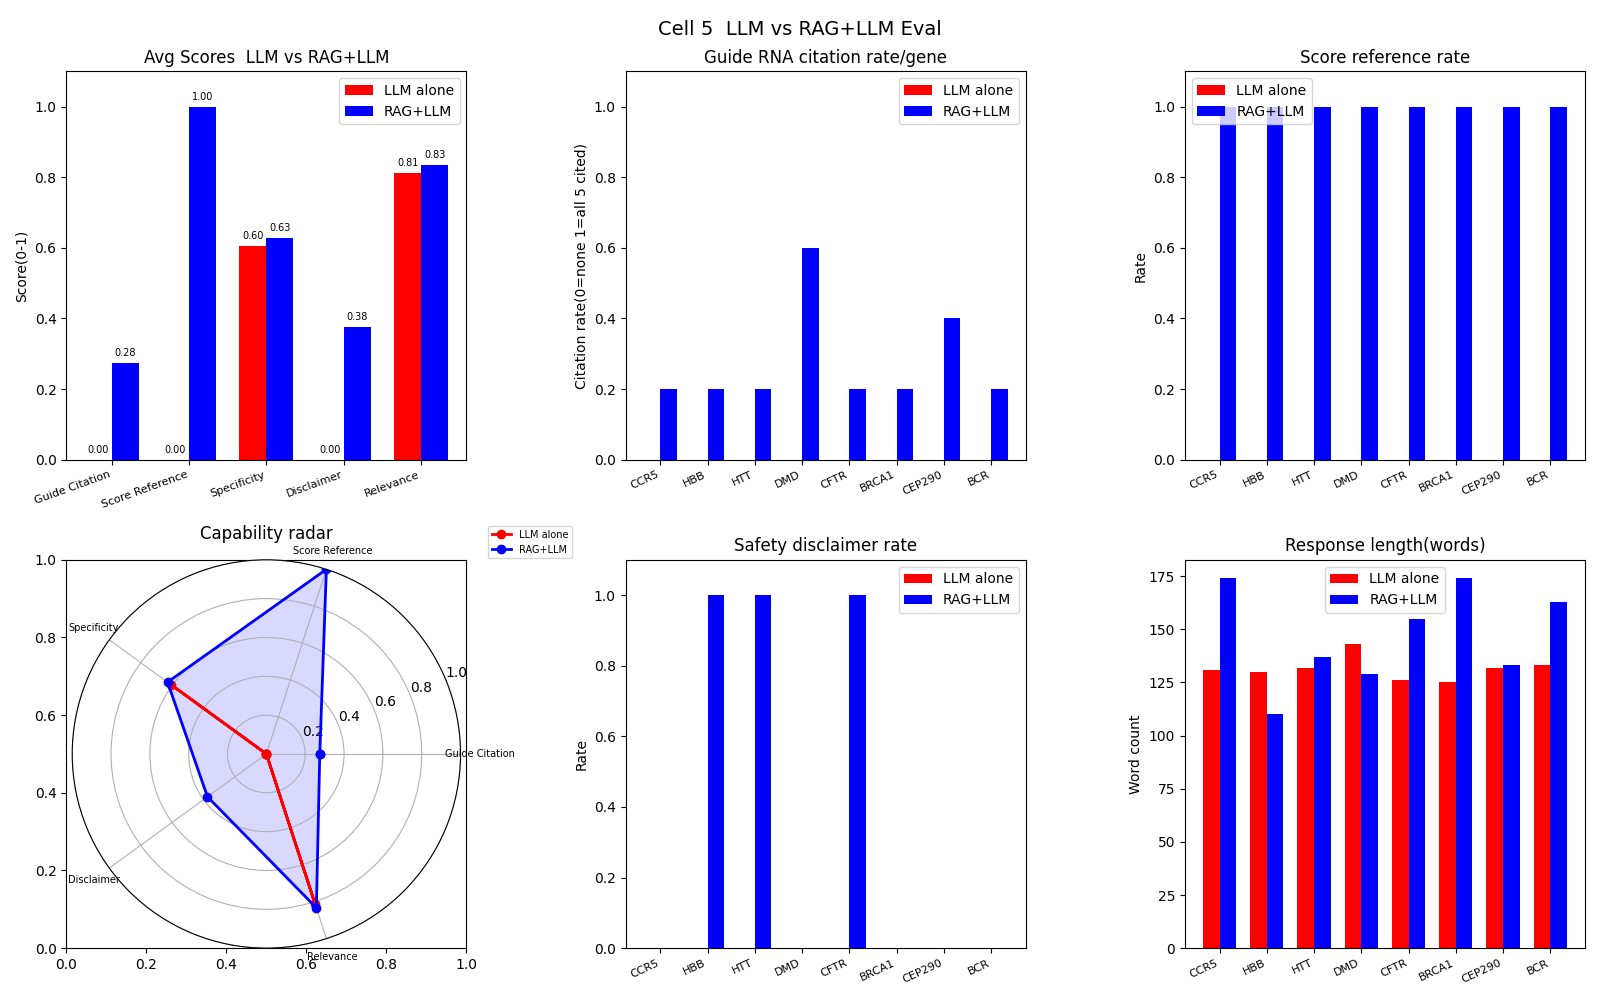

In [8]:
#cell 5 comparison and visualisation
#llm alone(cell 3) vs rag+llm(cell 4)
import numpy as np
Results_folder=r"C:\Users\user\Desktop\CRISPR-Cas9-Engineering-Platform-RAG\Results"
FROZEN_DIR=os.path.join(Results_folder,"frozen_data")
with open(os.path.join(FROZEN_DIR,"llm_responses.json"),encoding="utf-8") as f:
    llm_responses=json.load(f)
with open(os.path.join(FROZEN_DIR,"rag_responses.json"),encoding="utf-8") as f:
    rag_responses=json.load(f)
with open(os.path.join(FROZEN_DIR,"ranked_guides.json"),encoding="utf-8") as f:
    ranked_guides=json.load(f)
print(f"loaded: {len(llm_responses)} llm|{len(rag_responses)} rag")
DISEASE_TERMS={
    "CCR5":["ccr5","hiv","t-cell","co-receptor","resistance"],
    "HBB":["hbb","sickle","hemoglobin","beta-globin","anemia"],
    "HTT":["htt","huntington","neurodegeneration","cag","repeat"],
    "DMD":["dmd","dystrophin","duchenne","exon","muscular"],
    "CFTR":["cftr","cystic fibrosis","f508","chloride","lung"],
    "BRCA1":["brca1","dna repair","cancer","homologous","recombination"],
    "CEP290":["cep290","blindness","lca","retinal","photoreceptor"],
    "BCR":["bcr","abl","leukemia","cml","fusion","oncogene"],
}
DISCLAIMER_PHRASES=["validate experimentally","experimental validation","wet lab","in vitro","in vivo","consult","verify","laboratory","caution","should be validated","requires validation"]

#1st metric guide rna citation rate checks does the response refers?(main distinguisher between rag and llm)
def guide_citation(response, gene):
    guides=ranked_guides.get(gene,[])
    if not guides:
        return 0.0
    r=response.upper()
    cited=sum(1 for g in guides[:5] if g["guide_rna"] in r)
    return round(cited/5, 3)

#2nd metric specificity(does response mention gene specific disease terms?)
def specificity(response,gene):
    r=response.lower()
    terms=DISEASE_TERMS.get(gene,[gene.lower()])
    hits=sum(1 for t in terms if t in r)
    return round(hits/len(terms),3)

#3rd metric score reference rate(does response mention actual numerical scores like 90/100?)
def score_reference(response):
    #look for scores
    matches=re.findall(r'\b\d{2}/100\b|\bscore[:\s]+\d{2}\b',response,re.IGNORECASE)
    return 1.0 if matches else 0.0

#4th metric safety disclaimer rate
def disclaimer(response):
    r=response.lower()
    return 1.0 if any(d in r for d in DISCLAIMER_PHRASES) else 0.0

#5th metric response relevance(is the response on-topic for the gene and disease?)
def relevance(response,gene):
    r=response.lower()
    gene_hits=min(r.count(gene.lower())/3,1.0)
    disease_hits=min(sum(1 for t in DISEASE_TERMS.get(gene,[])
    if t in r)/3, 1.0)
    return round((gene_hits+disease_hits)/2, 3)

#run all metrics
metric_names=["Guide Citation","Score Reference","Specificity","Disclaimer","Relevance"]
results={}
print(f"\n{'Gene':<10} {'Metric':<20} {'LLM':>8} {'RAG+LLM':>10}")
for gene in llm_responses:
    llm_r=llm_responses[gene]["response"]
    rag_r=rag_responses[gene]["response"]
    llm_scores=[
        guide_citation(llm_r, gene),
        score_reference(llm_r),
        specificity(llm_r, gene),
        disclaimer(llm_r),
        relevance(llm_r, gene),
    ]
    rag_scores=[
        guide_citation(rag_r, gene),
        score_reference(rag_r),
        specificity(rag_r, gene),
        disclaimer(rag_r),
        relevance(rag_r, gene),
    ]
    results[gene]={"llm":llm_scores,"rag":rag_scores}
    for name,ls,rs in zip(metric_names,llm_scores,rag_scores):
        print(f"{gene:<10} {name:<20} {ls:>8.3f} {rs:>10.3f}")
    print()
avg_llm=[np.mean([results[g]["llm"][i] for g in results])
         for i in range(len(metric_names))]
avg_rag=[np.mean([results[g]["rag"][i] for g in results])
         for i in range(len(metric_names))]

print("\nFinal avg Scores")
print(f"{'Metric':<22} {'LLM':>8} {'RAG+LLM':>10} {'Winner':>10}")
for name,l,r in zip(metric_names,avg_llm,avg_rag):
    winner="RAG+LLM" if r>l else "LLM" if l>r else "Tie"
    print(f"{name:<22} {l:>8.3f} {r:>10.3f} {winner:>10}")

#Side by Side (3 genes)
print("\n Side by Side (3 genes)")
for gene in list(llm_responses.keys())[:3]:
    print(f"\n[{gene}]")
    print(f"Q: {llm_responses[gene]['question'][:80]}...")
    print(f"\nLLM ALONE:\n{llm_responses[gene]['response'][:400]}...")
    print(f"\nRAG+LLM:\n{rag_responses[gene]['response'][:400]}...")

#visualisation
fig,axes=plt.subplots(2,3,figsize=(16,10))
fig.suptitle("Cell 5  LLM vs RAG+LLM Eval",fontsize=14)
x=np.arange(len(metric_names))
w=0.35
bars1=axes[0,0].bar(x-w/2,avg_llm,w,label="LLM alone",color="red")
bars2=axes[0,0].bar(x+w/2,avg_rag,w,label="RAG+LLM",color="blue")
axes[0,0].set_title("Avg Scores  LLM vs RAG+LLM")
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(metric_names,rotation=20,ha="right",fontsize=8)
axes[0,0].set_ylim(0,1.1)
axes[0,0].set_ylabel("Score(0-1)")
axes[0,0].legend()
for bar in list(bars1)+list(bars2):
    axes[0,0].text(bar.get_x()+bar.get_width()/2,
                   bar.get_height()+0.02,
                   f"{bar.get_height():.2f}",ha="center",fontsize=7)

genes_list=list(results.keys())
cit_llm=[results[g]["llm"][0] for g in genes_list]
cit_rag=[results[g]["rag"][0] for g in genes_list]
x2=np.arange(len(genes_list))
axes[0,1].bar(x2-w/2,cit_llm,w,label="LLM alone",color="red")
axes[0,1].bar(x2+w/2,cit_rag,w,label="RAG+LLM",color="blue")
axes[0,1].set_title("Guide RNA citation rate/gene")
axes[0,1].set_xticks(x2)
axes[0,1].set_xticklabels(genes_list,rotation=25,ha="right",fontsize=8)
axes[0,1].set_ylim(0,1.1)
axes[0,1].set_ylabel("Citation rate(0=none 1=all 5 cited)")
axes[0,1].legend()

sr_llm=[results[g]["llm"][1] for g in genes_list]
sr_rag=[results[g]["rag"][1] for g in genes_list]
axes[0,2].bar(x2-w/2,sr_llm,w,label="LLM alone",color="red")
axes[0,2].bar(x2+w/2,sr_rag,w,label="RAG+LLM",color="blue")
axes[0,2].set_title("Score reference rate")
axes[0,2].set_xticks(x2)
axes[0,2].set_xticklabels(genes_list,rotation=25,ha="right",fontsize=8)
axes[0,2].set_ylim(0,1.1)
axes[0,2].set_ylabel("Rate")
axes[0,2].legend()

#radar chart
angles=np.linspace(0,2*np.pi,len(metric_names),endpoint=False).tolist()
angles+=angles[:1]
llm_vals=avg_llm+avg_llm[:1]
rag_vals=avg_rag+avg_rag[:1]
ax_radar=fig.add_subplot(2,3,4,polar=True)
ax_radar.plot(angles,llm_vals,"o-",linewidth=2,color="red",label="LLM alone")
ax_radar.fill(angles,llm_vals,alpha=0.15,color="red")
ax_radar.plot(angles,rag_vals,"o-",linewidth=2,color="blue",label="RAG+LLM")
ax_radar.fill(angles,rag_vals,alpha=0.15,color="blue")
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(metric_names,fontsize=7)
ax_radar.set_ylim(0,1)
ax_radar.set_title("Capability radar",pad=15)
ax_radar.legend(loc="upper right",bbox_to_anchor=(1.3,1.1),fontsize=7)

disc_llm=[results[g]["llm"][3] for g in genes_list]
disc_rag=[results[g]["rag"][3] for g in genes_list]
axes[1,1].bar(x2-w/2,disc_llm,w,label="LLM alone",color="red")
axes[1,1].bar(x2+w/2,disc_rag,w,label="RAG+LLM",color="blue")
axes[1,1].set_title("Safety disclaimer rate")
axes[1,1].set_xticks(x2)
axes[1,1].set_xticklabels(genes_list,rotation=25,ha="right",fontsize=8)
axes[1,1].set_ylim(0,1.1)
axes[1,1].set_ylabel("Rate")
axes[1,1].legend()

llm_len=[len(llm_responses[g]["response"].split()) for g in genes_list]
rag_len=[len(rag_responses[g]["response"].split()) for g in genes_list]
axes[1,2].bar(x2-w/2,llm_len,w,label="LLM alone",color="red")
axes[1,2].bar(x2+w/2,rag_len,w,label="RAG+LLM",color="blue")
axes[1,2].set_title("Response length(words)")
axes[1,2].set_xticks(x2)
axes[1,2].set_xticklabels(genes_list,rotation=25,ha="right",fontsize=8)
axes[1,2].set_ylabel("Word count")
axes[1,2].legend()
print("\nDMD LLM:")
print(results["DMD"]["llm"])
print("\nDMD RAG:")
print(results["DMD"]["rag"])
print("\nDMD RAG response:")
print(rag_responses["DMD"]["response"])
plt.tight_layout()
plot_out=os.path.join(Results_folder,"cell5_comparison.png")
plt.savefig(plot_out,dpi=100)
plt.close()
display(Image(filename=plot_out))